## Imports & Loads

In [1]:
CANVAS_SIZE = (235, 130) # mm 

In [2]:
from stroke_generation import Hyperparameters, KNearest, PaletteColorsOnly
from datatypes import StrokeSequence, LoadBrush
from visualisation import visualize_stroke_sequence, show_np_image, resize_image
from visualisation import show_np_image, rotate_if_vertical
from stroke_generation import StrokeGenerationSupervisor, generate_strokes_for_layer
from stroke_generation import calculate_etf_field
from stroke_generation import k_nearest
from distance import get_distance_heatmap
# from saliency import generate_clean_saliency

import numpy as np
from pathlib import Path
import math

from tqdm import tqdm # progress bar


# import matplotlib.pyplot as plt
from PIL import Image, ImageOps, ImageEnhance
from scipy.ndimage import gaussian_filter

from scipy.ndimage import center_of_mass
from skimage.segmentation import slic, mark_boundaries

Loading weights:   0%|          | 0/414 [00:00<?, ?it/s]

## Image Pre-loading

Image is vertical (683x1024). Rotating 90 degrees...


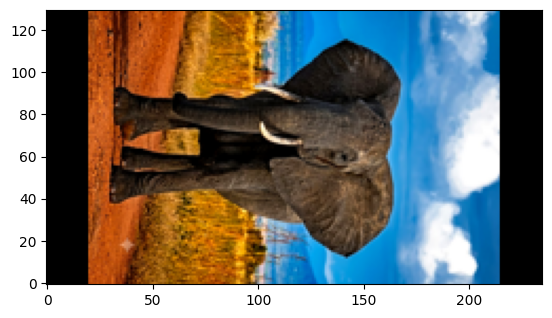

In [21]:
# 1. Load your PIL image
INPUT_PATH = Path("../images/elephant-ai.jpg")
IMAGE_NAME = INPUT_PATH.stem
pil_original_image = rotate_if_vertical(Image.open(INPUT_PATH).convert("RGB").transpose(Image.FLIP_TOP_BOTTOM))

enhancer = ImageEnhance.Contrast(pil_original_image)
contrast_factor = 1.2
pil_original_image = enhancer.enhance(contrast_factor)

# 2. Resize to 440x440 (assuming resize_image is defined elsewhere)
pil_resized_image = resize_image(pil_original_image, CANVAS_SIZE)

# GaussianBlur takes a 'radius' parameter. Higher radius = more blur.
# pil_blurred_image = pil_resized_image.filter(ImageFilter.GaussianBlur(radius=5))
# np_resized_blurred_image = np.array(pil_blurred_image)

# 3. Convert the original resized PIL image to a NumPy array (if still needed)
np_resized_image = np.array(pil_resized_image)
np_original_image = np.array(pil_original_image)

# Display the blurred image to verify
show_np_image(np_resized_image)

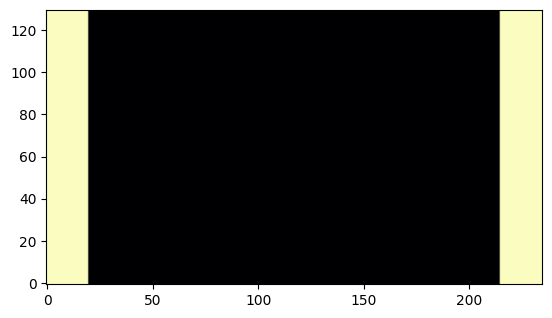

In [22]:
# 3. Create a "dummy" pure white image of the exact same original size
# This represents our "real pixels" mask BEFORE padding
mask_canvas = Image.new("L", pil_original_image.size, color=255)

# 4. Apply the exact same padding transformation to the mask canvas
# ImageOps.pad will scale and pad this mask identically to the elephant image
padded_mask_resized = ImageOps.pad(mask_canvas, CANVAS_SIZE, color=0)
np_padded_mask_resized = np.array(padded_mask_resized)

# 5. Convert mask to a 1 and 0 NumPy array
# Wherever the padded_mask is 255 (white), it's a real pixel (1). Otherwise, it's 0.
padding_mask = (np.array(padded_mask_resized) == 0).astype(np.uint8)

show_np_image(padding_mask, cmap="magma")


## Segmentation

(235, 130)
(130, 235, 3)


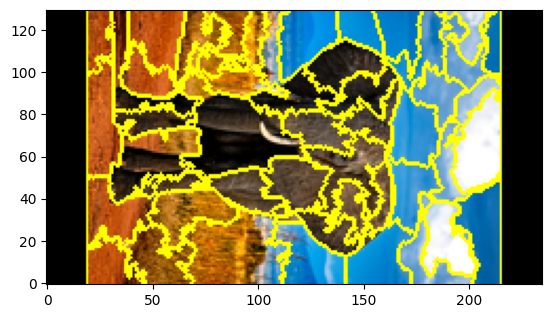

In [23]:
# 1. Run SLIC on the original image as you did
segments = slic(
    np_original_image,
    n_segments=70,
    compactness=10
)

# 2. Cast to int32 so PIL can handle it, then resize using Nearest Neighbor
segments_int32 = segments.astype(np.int32) # <--- Added this line
segments_pil = Image.fromarray(segments_int32)

resized_segments_pil = ImageOps.pad(
    segments_pil, 
    CANVAS_SIZE, 
    method=Image.Resampling.NEAREST, 
    color=0
)

print(resized_segments_pil.size)
print(np_resized_image.shape)

resized_segments = np.array(resized_segments_pil)


# 3. Calculate centroids on the NEW resized segments
for label in np.unique(resized_segments):
    # Mask out the background padding (label 0 might contain padding now)
    if label == 0: 
        continue
    centroid = center_of_mass(resized_segments == label)

show_np_image(mark_boundaries(np_resized_image, resized_segments))

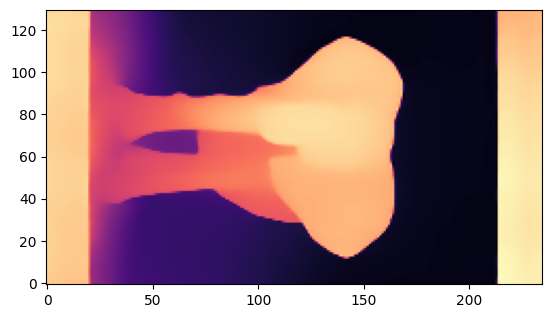

In [24]:
# blurred_saliency, img_cv = generate_clean_saliency(pil_resized_image)
depth_map = get_distance_heatmap(pil_resized_image)
show_np_image(depth_map, cmap="magma")


In [25]:
# Calculate the mean saliency per segment, excluding padded pixels.
segment_mean_saliency = []
real_pixel_mask = np_padded_mask_resized > 0

for segment_label in np.unique(resized_segments):
    if segment_label == 0:
        continue

    segment_mask = resized_segments == segment_label
    valid_segment_mask = segment_mask & real_pixel_mask

    if not np.any(valid_segment_mask):
        continue

    mean_saliency = float(depth_map[valid_segment_mask].mean())
    segment_mean_saliency.append((segment_label, mean_saliency, mean_saliency >= .5))
    # label, mean, extra_effort

segment_mean_saliency.sort(key=lambda item: item[1], reverse=True)

## Stroke Generation

Precompute the gradient

In [26]:
# # 1. Smooth the image to get a reliable, non-noisy gradient field
if np_resized_image.ndim == 3:
    gray = 0.299 * np_resized_image[:,:,0] + 0.587 * np_resized_image[:,:,1] + 0.114 * np_resized_image[:,:,2]
else:
    gray = np_resized_image.copy()

W, H, _ = np_resized_image.shape

gray_smoothed = gaussian_filter(gray, sigma=1.5)
unit_x, unit_y = calculate_etf_field(blurred_gray=gray_smoothed)
vector_field = (unit_x, unit_y)

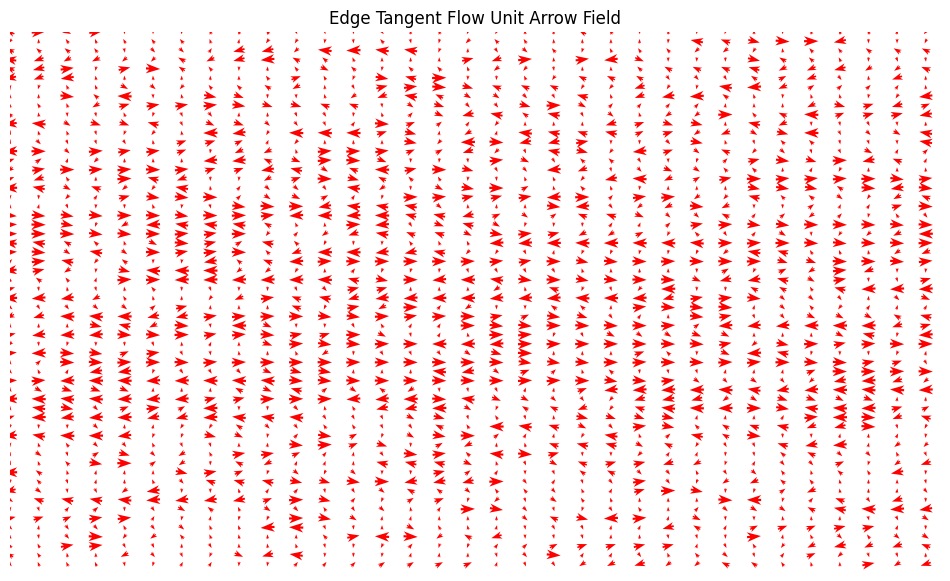

In [27]:
import matplotlib.pyplot as plt

# 3. Generate coordinates for plotting the quiver arrows
# (Quiver plots look messy if you plot every single pixel, so we step/sample every 10th pixel)
step = 4
y_indices, x_indices = np.mgrid[0:H:step, 0:W:step]

# Flatten arrays for matplotlib quiver
xx = x_indices.ravel()
yy = y_indices.ravel()
sample_x = unit_x[::step, ::step].ravel()
sample_y = unit_y[::step, ::step].ravel()

length = np.sqrt(sample_x ** 2 + sample_y ** 2)
zero_mask = length == 0

if np.any(zero_mask):
    # Generate random angles for the zero-length vectors
    random_angles = np.random.uniform(0, 2 * np.pi, size=np.sum(zero_mask))

    # Assign random unit vector coordinates to those positions
    sample_x[zero_mask] = np.cos(random_angles)
    sample_y[zero_mask] = np.sin(random_angles)

    # Update the length array to 1.0 for these new vectors so division doesn't fail
    length[zero_mask] = 1.0

# 4. Plotting
fig, ax = plt.subplots(figsize=(12, 7))

ax.quiver(
    xx,
    yy,
    sample_x / length,
    sample_y / length,
    angles="xy",
    scale_units="xy",
    scale=0.5,  # Adjust scale if arrows look too long/short
    width=0.003,  # Scaled down slightly so it's less crowded
    headwidth=4.5,
    headlength=6.5,
    headaxislength=5.0,
    pivot="mid",
    color="red",  # Added color so arrows stand out against the image
)

ax.set_title("Edge Tangent Flow Unit Arrow Field")
ax.set_xlim(0, W)
ax.set_ylim(H, 0)  # Inverted Y-axis to match typical image coordinate space
ax.axis("off")
plt.show()

In [28]:
Hyperparameters.COLOR_METHOD = PaletteColorsOnly()

H, W, _ = np_resized_image.shape

stroke_sequence = StrokeSequence(image_size=(W, H))
coverage_mask = ~np_padded_mask_resized

stroke_generation_supervisor = StrokeGenerationSupervisor()

if type(Hyperparameters.COLOR_METHOD) == KNearest:
    np_k_nearest = k_nearest(
        np_resized_image,
        k=Hyperparameters.COLOR_METHOD.k
    )

    show_np_image(np_k_nearest)
else:
    np_k_nearest = None

for label, mean_saliency, extra_effort in tqdm(segment_mean_saliency):
    segment_mask = (resized_segments == label)
    if not np.any(segment_mask):
        continue

    stroke_generation_supervisor.brush_diameter = 3

    generate_strokes_for_layer(
        vector_field=vector_field,
        stroke_sequence=stroke_sequence, 
        resized_segments=resized_segments, 
        label=label, 
        extra_effort=extra_effort,
        np_image=np_resized_image,
        coverage_mask=coverage_mask,
        padding_mask=np_padded_mask_resized,
        stroke_generation_supervisor=stroke_generation_supervisor,
        np_k_nearest=np_k_nearest,
    )

100%|██████████| 45/45 [00:04<00:00,  9.47it/s]


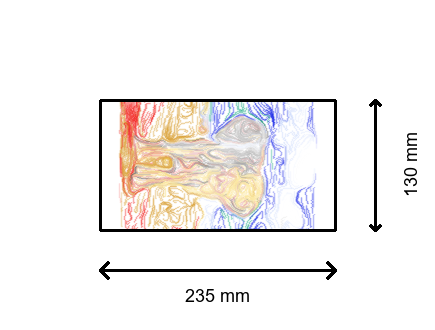

In [29]:
visualize_stroke_sequence(stroke_sequence)

In [30]:
# Test evaluation
from evalutation import evaluate

evaluate(pil_resized_image, stroke_sequence, np_padded_mask_resized)

2784.767578125

## Stroke Reordering

In [31]:
color_buckets = {}

queue_length = {
    "#d69927": 10,
    "#f5d049": 5,
    "#f01713": 8,
    "#0fba1a": 15,
    "#1725e6": 8,
    "#bd4bbe": 15,
    "#630d0a": 5,
    "#171515": 5,
    "#cf474d": 12,
    "#98b3f5": 6,
    "#0aa37a": 20,
    "#480ce8": 20,
}

# sort in color buckets
for stroke in stroke_sequence.strokes:
    color_key = tuple(stroke.color)
    color_buckets.setdefault(color_key, []).append(stroke)

# color buckets to queues
stroke_sequence.strokes = []
for bucket in color_buckets.values():
    bucket.sort(key=lambda stroke: stroke.pigment, reverse=True)
    queue_count = math.ceil(len(bucket) / queue_length[bucket[0].hex_color])
    bucket_queues = [[] for _ in range(queue_count)]

    for index, stroke in enumerate(bucket):
        bucket_queues[index % queue_count].append(stroke)

    # set starting value of each buckets
    for index, bucket_queue in enumerate(bucket_queues):
        bucket_queue.insert(
            0, 
            LoadBrush(
                color = bucket_queue[0].color,
                pigment = bucket_queue[0].pigment,
                deep_clean = (index == 0), # deep clean between different colors
            )
        )

    for bucket_queue in bucket_queues:
        stroke_sequence.strokes.extend(bucket_queue)

## Stroke Statistics
We counted the reason for a stroke to be declined.
Now, we will create a graph to visualize this.

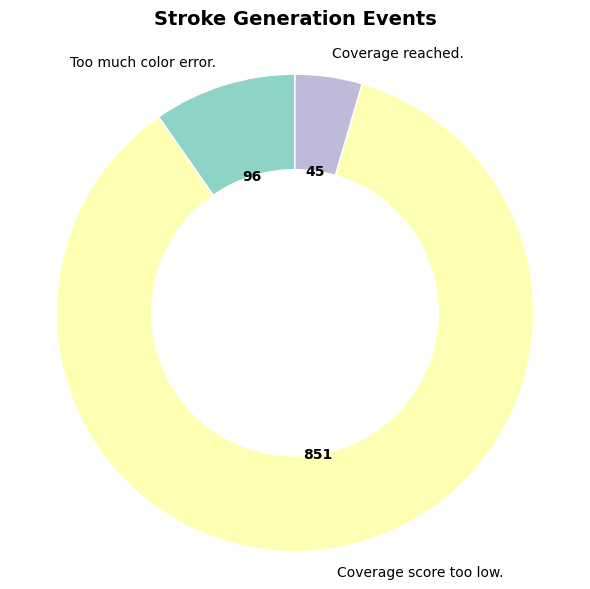

In [32]:
stroke_generation_supervisor.plot_decline_reasons()

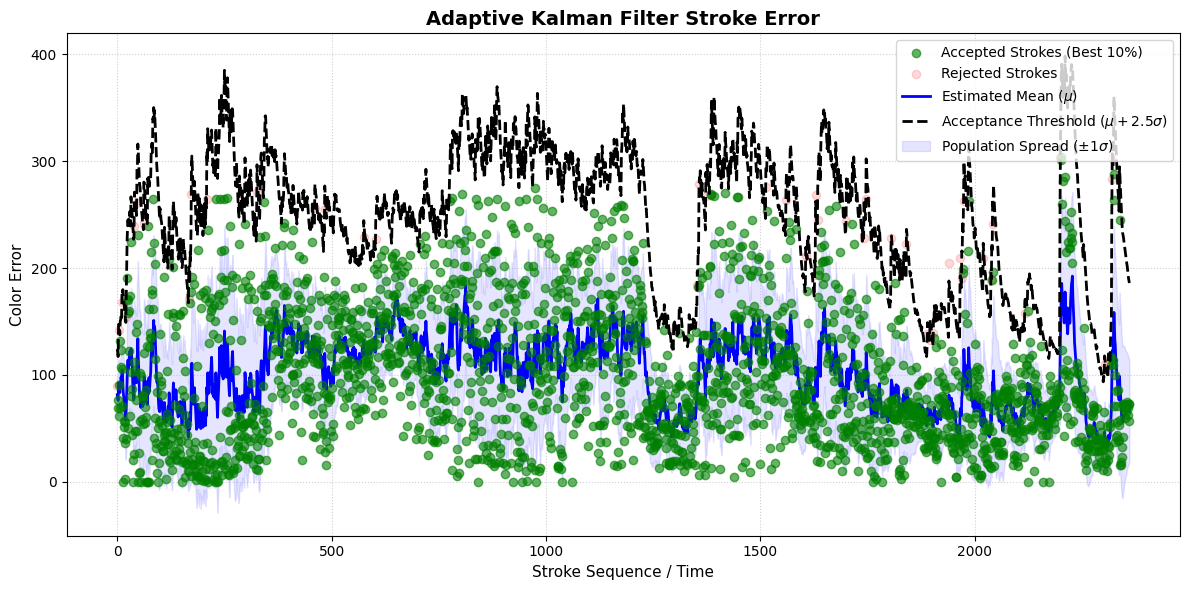

In [33]:
stroke_generation_supervisor.plot_color_error_history()

## Visualisation

Create a video from the strokes.

In [34]:
from visualisation import animate_stroke_sequence

animate_stroke_sequence(stroke_sequence, filename="render")

Start video rendering...


100%|██████████| 1691/1691 [00:09<00:00, 176.55it/s]


Save the strokes to a json file.

In [35]:
stroke_sequence.save_to_json(Path("data/stroke_renders") / f"{IMAGE_NAME}.json")